In [ ]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\ksili\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

SyntaxError: invalid syntax (3435186165.py, line 1)

In [ ]:
pip install glob

In [ ]:
pip install zipfile

In [ ]:
import glob, zipfile
import pandas as pd
import pickle
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
pd.set_option("mode.string_storage", "python")
COLS = ["FlightDate", "Reporting_Airline", "Origin", "Dest", "CRSDepTime",
        "CRSElapsedTime", "Distance", "DepDelay", "ArrDelay", "ArrDel15",
        "Cancelled", "Diverted"]


def read(path):
    with zipfile.ZipFile(path) as z:
        name = [n for n in z.namelist() if n.endswith(".csv")][0]
        return pd.read_csv(z.open(name), usecols=COLS)


df = pd.concat([read(f) for f in sorted(glob.glob("us-flights-2026-raw/monthly-zips/*.zip"))],
               ignore_index=True)

df = df[(df.Cancelled == 0) & (df.Diverted == 0)].drop(columns=["Cancelled", "Diverted"])
df = df.dropna(subset=["ArrDelay", "DepDelay", "CRSElapsedTime"])

df["FlightDate"] = pd.to_datetime(df.FlightDate)
df["Month"] = df.FlightDate.dt.month
df["DayOfWeek"] = df.FlightDate.dt.dayofweek
df["DepHour"] = df.CRSDepTime // 100 % 24
df["ArrDel15"] = df.ArrDel15.fillna(df.ArrDelay >= 15).astype(int)

df.to_pickle("flights_2026.pkl")
print(df.shape)
print(df.head())

(3402619, 13)
  FlightDate Reporting_Airline Origin Dest  CRSDepTime  DepDelay  ArrDelay  \
0 2026-01-01                AA    JFK  LAX         700      -3.0      43.0   
1 2026-01-02                AA    JFK  LAX         700      -6.0       1.0   
2 2026-01-03                AA    JFK  LAX         700      -2.0     -10.0   
3 2026-01-04                AA    JFK  LAX         729      -4.0     -18.0   
4 2026-01-05                AA    JFK  LAX         729      -9.0      -3.0   

   ArrDel15  CRSElapsedTime  Distance  Month  DayOfWeek  DepHour  
0         1           381.0    2475.0      1          3        7  
1         0           381.0    2475.0      1          4        7  
2         0           381.0    2475.0      1          5        7  
3         0           387.0    2475.0      1          6        7  
4         0           387.0    2475.0      1          0        7  


## Анализ данных

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_pickle("flights_2026.pkl")

print("рейсов:", len(df), "| опаздывают на 15+ мин:", round(df.ArrDel15.mean(), 2))
print("ArrDelay: медиана", df.ArrDelay.median(), "мин, среднее", round(df.ArrDelay.mean(), 1), "мин")
print("\nкорреляция с ArrDelay:")
print(df.corr(numeric_only=True).ArrDelay.drop("ArrDelay").sort_values(ascending=False).round(2))

рейсов: 3402619 | опаздывают на 15+ мин: 0.22
ArrDelay: медиана -7.0 мин, среднее 7.4 мин

корреляция с ArrDelay:


DepDelay          0.97
ArrDel15          0.57
CRSDepTime        0.10
DepHour           0.10
Month             0.02
DayOfWeek         0.01
Distance         -0.01
CRSElapsedTime   -0.02
Name: ArrDelay, dtype: float64


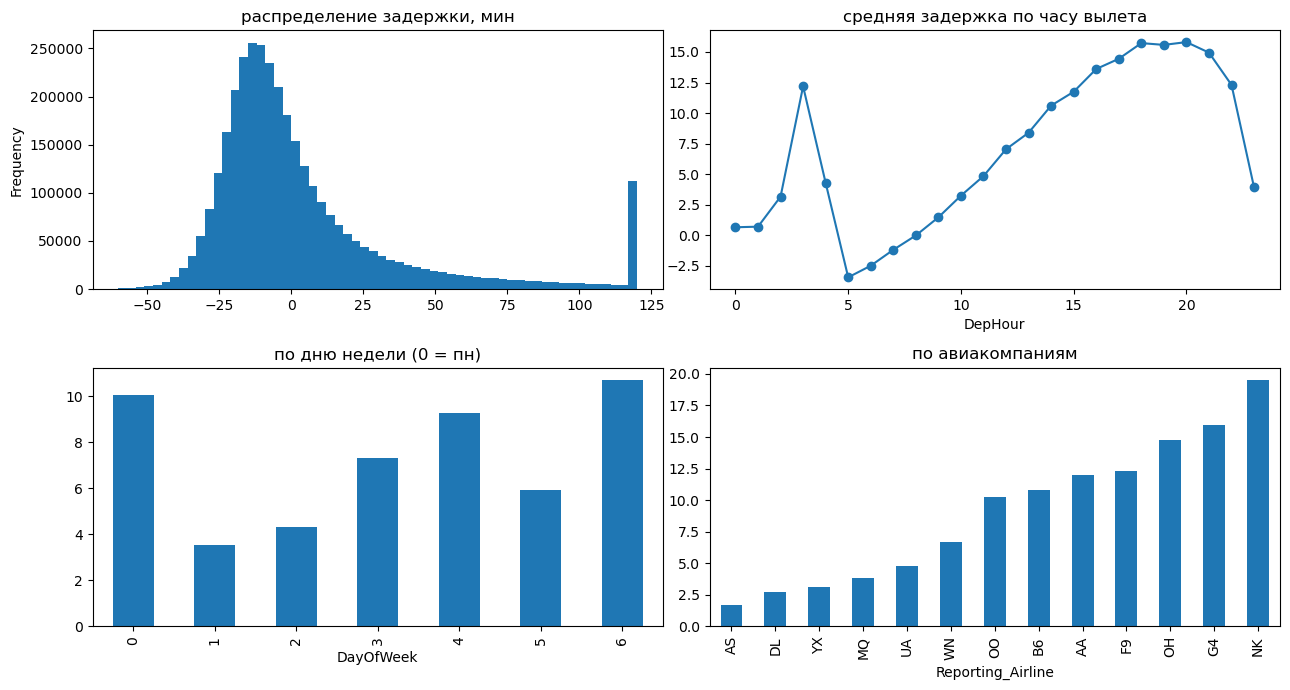

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))

df.ArrDelay.clip(-60, 120).plot.hist(bins=60, ax=ax[0, 0], title="распределение задержки, мин")
df.groupby("DepHour").ArrDelay.mean().plot(ax=ax[0, 1], marker="o", title="средняя задержка по часу вылета")
df.groupby("DayOfWeek").ArrDelay.mean().plot.bar(ax=ax[1, 0], title="по дню недели (0 = пн)")
df.groupby("Reporting_Airline").ArrDelay.mean().sort_values().plot.bar(ax=ax[1, 1], title="по авиакомпаниям")

plt.tight_layout()
plt.show()

**Выводы:** медиана задержки -7 мин, то есть 61% рейсов прилетают раньше расписания, а на 15+ минут опаздывают 22%.
`DepDelay` почти полностью определяет `ArrDelay` (корреляция 0.97) — в пути задержка почти не меняется, остальные признаки слабые.
Из них заметнее всего час вылета: утренние рейсы прилетают раньше, к вечеру средняя задержка растёт до ~16 мин.
Авиакомпании различаются в разы: от +2 мин (AS, DL) до +20 мин (NK).

# Модели

In [ ]:
F = ["DepDelay", "Month", "DayOfWeek", "DepHour", "Distance", "CRSElapsedTime",
     "Reporting_Airline", "Origin", "Dest"]

df = pd.read_pickle("flights_2026.pkl")
for c in ["Reporting_Airline", "Origin", "Dest"]:
    df[c] = df[c].astype("category").cat.codes

train = df[df.FlightDate < "2026-06-01"]
test = df[df.FlightDate >= "2026-06-01"]

base = DummyRegressor().fit(train[F], train.ArrDelay)
m = HistGradientBoostingRegressor(max_iter=300, random_state=0).fit(train[F], train.ArrDelay)

for name, p in [("baseline", base.predict(test[F])), ("модель", m.predict(test[F]))]:
    print(f"{name:9} MAE {mean_absolute_error(test.ArrDelay, p):5.1f} мин   "
          f"R2 {r2_score(test.ArrDelay, p):6.3f}")

baseline  MAE  30.2 мин   R2 -0.006
модель    MAE  10.9 мин   R2  0.862


## Сравнение моделей

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

preds = {"прогноз = DepDelay": test.DepDelay.values, "бустинг": m.predict(test[F])}
for name, est in [("среднее", DummyRegressor()),
                  ("линейная", LinearRegression()),
                  ("дерево", DecisionTreeRegressor(max_depth=8, random_state=0))]:
    preds[name] = est.fit(train[F], train.ArrDelay).predict(test[F])

res = pd.DataFrame({n: {"MAE": mean_absolute_error(test.ArrDelay, p),
                        "R2": r2_score(test.ArrDelay, p)} for n, p in preds.items()}).T
res = res.sort_values("MAE")
res.round(2)

,MAE,R2
дерево,10.13,0.95
линейная,10.15,0.95
бустинг,10.93,0.86
прогноз = DepDelay,12.16,0.94
среднее,30.25,-0.01


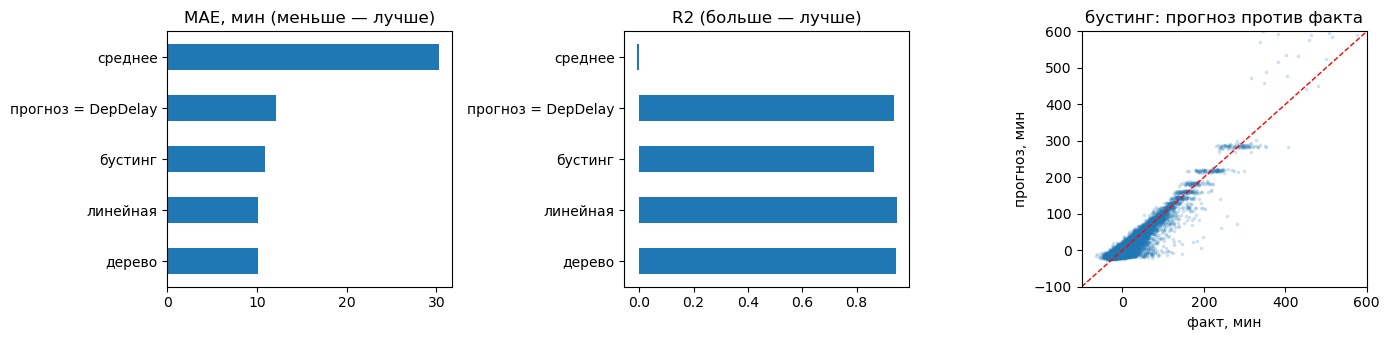

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))

res.MAE.plot.barh(ax=ax[0], title="MAE, мин (меньше — лучше)")
res.R2.plot.barh(ax=ax[1], title="R2 (больше — лучше)")

i = np.random.default_rng(0).choice(len(test), 15000, replace=False)
ax[2].scatter(test.ArrDelay.values[i], preds["бустинг"][i], s=3, alpha=0.15)
ax[2].plot([-100, 600], [-100, 600], "r--", lw=1)
ax[2].set(title="бустинг: прогноз против факта", xlabel="факт, мин", ylabel="прогноз, мин",
          xlim=(-100, 600), ylim=(-100, 600))

plt.tight_layout()
plt.show()

**Выводы:** ближе всех к правде линейная регрессия и дерево (MAE ~10.1 мин), бустинг чуть хуже по MAE и заметно хуже по R2 (0.86 против 0.95).
Эвристика «прогноз = DepDelay» вообще без обучения даёт R2 0.94 — почти как модели, то есть основную работу делает один признак.
Бустинг проседает потому, что деревья не экстраполируют: его прогноз упирается в ~1050 мин, хотя в данных задержки доходят до 2750 мин.